In [ ]:
!pip install smt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.3 MB/s eta 0:00:00


--- Run: 1/5 ---
Iter 00 | Calls to G: 6 | Max EFF: 2.124385e-01 | Pf: 0.000000e+00
Iter 01 | Calls to G: 7 | Max EFF: 1.197543e+00 | Pf: 3.000000e-03
Iter 02 | Calls to G: 8 | Max EFF: 1.418018e+00 | Pf: 5.770000e-02
Iter 03 | Calls to G: 9 | Max EFF: 6.088044e-01 | Pf: 0.000000e+00
Iter 04 | Calls to G: 10 | Max EFF: 1.164270e+00 | Pf: 1.044000e-01
Iter 05 | Calls to G: 11 | Max EFF: 6.477037e-01 | Pf: 1.065000e-01
Iter 06 | Calls to G: 12 | Max EFF: 9.098611e-01 | Pf: 2.300000e-03
Iter 07 | Calls to G: 13 | Max EFF: 6.717571e-01 | Pf: 2.400000e-03
Iter 08 | Calls to G: 14 | Max EFF: 4.660040e-01 | Pf: 2.400000e-03
Iter 09 | Calls to G: 15 | Max EFF: 1.556331e+00 | Pf: 1.820000e-02
Iter 10 | Calls to G: 16 | Max EFF: 8.760788e-01 | Pf: 1.750000e-02
Iter 11 | Calls to G: 17 | Max EFF: 5.083838e-01 | Pf: 3.440000e-02
Iter 12 | Calls to G: 18 | Max EFF: 2.987955e-01 | Pf: 3.570000e-02
Iter 13 | Calls to G: 19 | Max EFF: 3.405049e-01 | Pf: 3.260000e-02
Iter 14 | Calls to G: 20 | Max EFF:

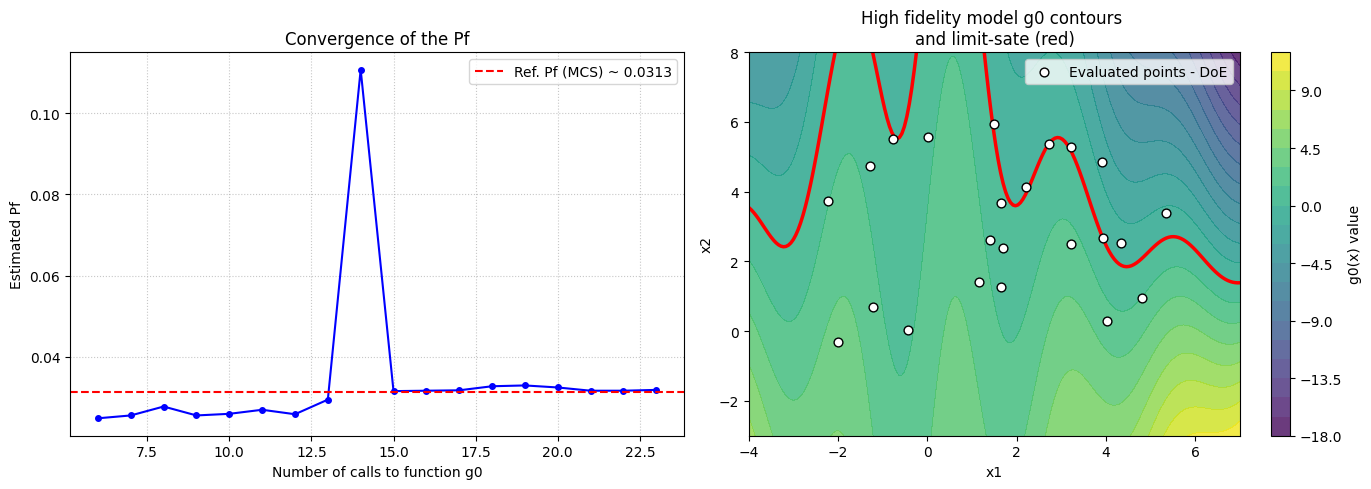

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from smt.surrogate_models import KRG

class AKMCS:
    def __init__(self, performance_function, population, n_init=6, eff_stop=0.001):
        self.g_func = performance_function
        self.S = population.copy()
        self.n_mc = self.S.shape[0]
        self.dim = self.S.shape[1]
        self.n_init = n_init
        self.eff_stop = eff_stop

        self.doe_x = None
        self.doe_y = None
        self.pf_history = []

    def init_doe(self):
        idx = np.random.choice(self.S.shape[0], self.n_init, replace=False)
        self.doe_x = self.S[idx]
        self.doe_y = self.g_func(self.doe_x)
        self.S = np.delete(self.S, idx, axis=0)

    def run(self):
        self.init_doe()
        iteration = 0

        while True:
            model = KRG(print_global=False)
            model.set_training_values(self.doe_x, self.doe_y)
            model.train()
            self.model = model

            y_pred = model.predict_values(self.S)
            y_var = model.predict_variances(self.S)
            y_std = np.sqrt(np.maximum(y_var, 1e-10))

            a = 0.0
            epsilon = 2.0 * y_std
            a_minus = a - epsilon
            a_plus = a + epsilon

            z1 = (a - y_pred) / y_std
            z2 = (a_minus - y_pred) / y_std
            z3 = (a_plus - y_pred) / y_std

            term1 = (y_pred - a) * (2 * norm.cdf(z1) - norm.cdf(z2) - norm.cdf(z3))
            term2 = y_std * (2 * norm.pdf(z1) - norm.pdf(z2) - norm.pdf(z3))
            term3 = epsilon * (norm.cdf(z3) - norm.cdf(z2))

            eff_val = term1 - term2 + term3
            max_eff_idx = np.argmax(eff_val)
            max_eff = eff_val[max_eff_idx][0]

            all_preds = np.vstack((self.doe_y, y_pred))
            pf = np.sum(all_preds <= 0) / self.n_mc
            self.pf_history.append(pf)

            print(f"Iter {iteration:02d} | Calls to G: {len(self.doe_y)} | Max EFF: {max_eff:.6e} | Pf: {pf:.6e}")

            if max_eff < self.eff_stop:
                print("\n Stopping criterion reached (max(EFF) < 0.001)")
                return pf

            x_new = self.S[max_eff_idx:max_eff_idx+1]
            y_new = self.g_func(x_new)

            self.doe_x = np.vstack((self.doe_x, x_new))
            self.doe_y = np.vstack((self.doe_y, y_new))
            self.S = np.delete(self.S, max_eff_idx, axis=0)
            iteration += 1

# Application - AMGPRA, Example 5.1 - Reproduction: 5 times
def g0_function(x):
    x1 = x[:, 0]
    x2 = x[:, 1]

    term1 = (x1**2 + 4) * (x2 - 1) / 20.0
    term2 = np.sin(2.5 * x1)

    return (2.0 - term1 + term2).reshape(-1, 1)

if __name__ == "__main__":
    n_runs = 5
    n_mcs_train = 10000
    n_mcs_eval = 1000000
    dim = 2

    all_pfs = []
    all_calls = []

    for run_idx in range(n_runs):
        print(f"--- Run: {run_idx + 1}/{n_runs} ---")

        S_train = np.zeros((n_mcs_train, dim))
        S_train[:, 0] = np.random.normal(loc=1.5, scale=1.0, size=n_mcs_train)
        S_train[:, 1] = np.random.normal(loc=2.5, scale=1.0, size=n_mcs_train)

        solver = AKMCS(performance_function=g0_function, population=S_train, n_init=6, eff_stop=0.001)
        solver.run()

        S_eval = np.zeros((n_mcs_eval, dim))
        S_eval[:, 0] = np.random.normal(loc=1.5, scale=1.0, size=n_mcs_eval)
        S_eval[:, 1] = np.random.normal(loc=2.5, scale=1.0, size=n_mcs_eval)

        y_pred_final = solver.model.predict_values(S_eval)
        final_pf = np.sum(y_pred_final <= 0) / n_mcs_eval

        all_pfs.append(final_pf)
        all_calls.append(len(solver.doe_y))

        print(f"End Run {run_idx + 1}: Number of calls to g0 = {len(solver.doe_y)}, Pf = {final_pf:.6e}\n")

    print("=========================================")
    print("Average results for 5 runs")
    print("=========================================")
    print(f"Estimated Pf: {np.mean(all_pfs):.6e} (Ref. ~ 3.13e-2)")
    print(f"Average number of calls to g0: {np.mean(all_calls):.1f} (Ref. ~ 45.2)")



    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    calls_axis = range(solver.n_init, solver.n_init + len(solver.pf_history))
    plt.plot(calls_axis, solver.pf_history, marker='o', linestyle='-', color='b', markersize=4)
    plt.axhline(y=0.0313, color='r', linestyle='--', label='Ref. Pf (MCS) ~ 0.0313')
    plt.xlabel('Number of calls to function g0')
    plt.ylabel('Estimated Pf')
    plt.title('Convergence of the Pf')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()

    plt.subplot(1, 2, 2)

    x1_range = np.linspace(-4, 7, 200)
    x2_range = np.linspace(-3, 8, 200)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    X_grid = np.column_stack((X1.flatten(), X2.flatten()))

    Z = g0_function(X_grid).reshape(X1.shape)

    contour_bg = plt.contourf(X1, X2, Z, levels=20, cmap='viridis', alpha=0.8)
    plt.colorbar(contour_bg, label='g0(x) value')

    plt.contour(X1, X2, Z, levels=[0], colors='red', linewidths=2.5)

    plt.scatter(solver.doe_x[:, 0], solver.doe_x[:, 1], color='white', edgecolor='black',
                s=40, label='Evaluated points - DoE', zorder=3)

    plt.xlim([-4, 7])
    plt.ylim([-3, 8])
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('High fidelity model g0 contours \nand limit-sate (red)')
    plt.legend()

    plt.tight_layout()
    plt.show()

Démarrage de 5 lancements pour l'Oscillateur (6D)...

--- RUN 1/5 ---
Iter 00 | Calls to G: 12 | Max EFF: 1.253674e-01 | Pf: 4.000000e-04
Iter 01 | Calls to G: 13 | Max EFF: 5.386586e-02 | Pf: 1.400000e-03
Iter 02 | Calls to G: 14 | Max EFF: 3.856738e-02 | Pf: 1.400000e-03
Iter 03 | Calls to G: 15 | Max EFF: 4.177264e-02 | Pf: 1.300000e-03
Iter 04 | Calls to G: 16 | Max EFF: 1.376269e-02 | Pf: 1.400000e-03
Iter 05 | Calls to G: 17 | Max EFF: 9.558959e-03 | Pf: 1.300000e-03
Iter 06 | Calls to G: 18 | Max EFF: 1.258797e-03 | Pf: 1.300000e-03
Iter 07 | Calls to G: 19 | Max EFF: 4.512623e-03 | Pf: 1.300000e-03
Iter 08 | Calls to G: 20 | Max EFF: 7.204538e-05 | Pf: 1.300000e-03

 Stopping criterion reached (max(EFF) < 0.001)
-> Fin du Run 1 : Appels = 20, Pf = 7.600000e-04, Erreur = 7.32%

--- RUN 2/5 ---
Iter 00 | Calls to G: 12 | Max EFF: 5.962808e-02 | Pf: 8.000000e-04
Iter 01 | Calls to G: 13 | Max EFF: 2.601029e-02 | Pf: 8.000000e-04
Iter 02 | Calls to G: 14 | Max EFF: 6.180439e-02 | P

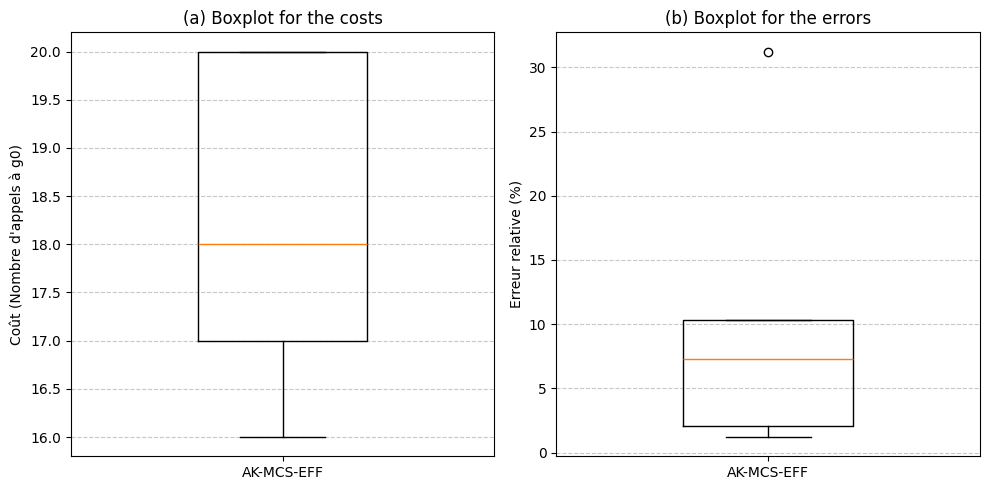

In [ ]:
# Oscillateur (6D)
def g0_oscillator(x):
    """
    Variables dans l'ordre : m, k1, k2, r, F1, t1
    """
    m = x[:, 0]
    k1 = x[:, 1]
    k2 = x[:, 2]
    r = x[:, 3]
    F1 = x[:, 4]
    t1 = x[:, 5]

    omega0 = np.sqrt((k1 + k2) / m)
    term = (2 * F1) / (m * omega0**2) * np.sin(omega0 * t1 / 2.0)
    g_val = 3 * r - np.abs(term)

    return g_val.reshape(-1, 1)

if __name__ == "__main__":
    n_runs = 5
    n_mcs_train = 10000
    n_mcs_eval = 1000000
    dim = 6
    means = [1.0, 1.0, 0.1, 0.65, 1.0, 1.0]
    stds = [0.05, 0.1, 0.01, 0.05, 0.2, 0.2]

    ref_pf = 8.2e-4

    all_pfs = []
    all_calls = []
    all_errors = []

    for run_idx in range(n_runs):
        print(f"--- RUN {run_idx + 1}/{n_runs} ---")

        S_train = np.zeros((n_mcs_train, dim))
        for i in range(dim):
            S_train[:, i] = np.random.normal(loc=means[i], scale=stds[i], size=n_mcs_train)

        solver = AKMCS(performance_function=g0_oscillator, population=S_train, n_init=12, eff_stop=0.001)
        solver.run()

        S_eval = np.zeros((n_mcs_eval, dim))
        for i in range(dim):
            S_eval[:, i] = np.random.normal(loc=means[i], scale=stds[i], size=n_mcs_eval)

        y_pred_final = solver.model.predict_values(S_eval)
        final_pf = np.sum(y_pred_final <= 0) / n_mcs_eval

        calls = len(solver.doe_y)
        error = abs(final_pf - ref_pf) / ref_pf * 100

        all_pfs.append(final_pf)
        all_calls.append(calls)
        all_errors.append(error)

        print(f"-> Fin du Run {run_idx + 1} : Appels = {calls}, Pf = {final_pf:.6e}, Erreur = {error:.2f}%\n")

    print("=========================================")
    print(" RÉSULTATS MOYENS SUR LES 5 LANCEMENTS   ")
    print("=========================================")
    print(f"Pf moyen     : {np.mean(all_pfs):.6e} (Réf : {ref_pf})")
    print(f"Coût moyen   : {np.mean(all_calls):.1f} appels (Réf AK-MCS : 50.8)")
    print(f"Erreur moy.  : {np.mean(all_errors):.2f}% (Réf AK-MCS : 0.25%)")


    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.boxplot(all_calls, widths=0.4)
    plt.xticks([1], ['AK-MCS-EFF'])
    plt.ylabel('Coût (Nombre d\'appels à g0)')
    plt.title('(a) Boxplot for the costs')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.boxplot(all_errors, widths=0.4)
    plt.xticks([1], ['AK-MCS-EFF'])
    plt.ylabel('Erreur relative (%)')
    plt.title('(b) Boxplot for the errors')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

Démarrage de 5 lancements pour le problème 10D...

--- RUN 1/5 ---
Iter 00 | Calls to G: 12 | Max EFF: 1.477997e+00 | Pf: 0.000000e+00
Iter 01 | Calls to G: 13 | Max EFF: 1.568247e+00 | Pf: 1.228000e-02
Iter 02 | Calls to G: 14 | Max EFF: 1.089525e+00 | Pf: 8.230000e-03
Iter 03 | Calls to G: 15 | Max EFF: 1.336631e-02 | Pf: 2.500000e-03
Iter 04 | Calls to G: 16 | Max EFF: 1.139215e-02 | Pf: 2.500000e-03
Iter 05 | Calls to G: 17 | Max EFF: 7.173713e-03 | Pf: 2.500000e-03
Iter 06 | Calls to G: 18 | Max EFF: 6.735986e-03 | Pf: 2.500000e-03
Iter 07 | Calls to G: 19 | Max EFF: 4.387530e-03 | Pf: 2.500000e-03
Iter 08 | Calls to G: 20 | Max EFF: 3.325778e-03 | Pf: 2.500000e-03
Iter 09 | Calls to G: 21 | Max EFF: 2.913082e-03 | Pf: 2.500000e-03
Iter 10 | Calls to G: 22 | Max EFF: 2.684895e-03 | Pf: 2.500000e-03
Iter 11 | Calls to G: 23 | Max EFF: 2.094130e-03 | Pf: 2.500000e-03
Iter 12 | Calls to G: 24 | Max EFF: 1.821717e-03 | Pf: 2.500000e-03
Iter 13 | Calls to G: 25 | Max EFF: 1.531904e-03 

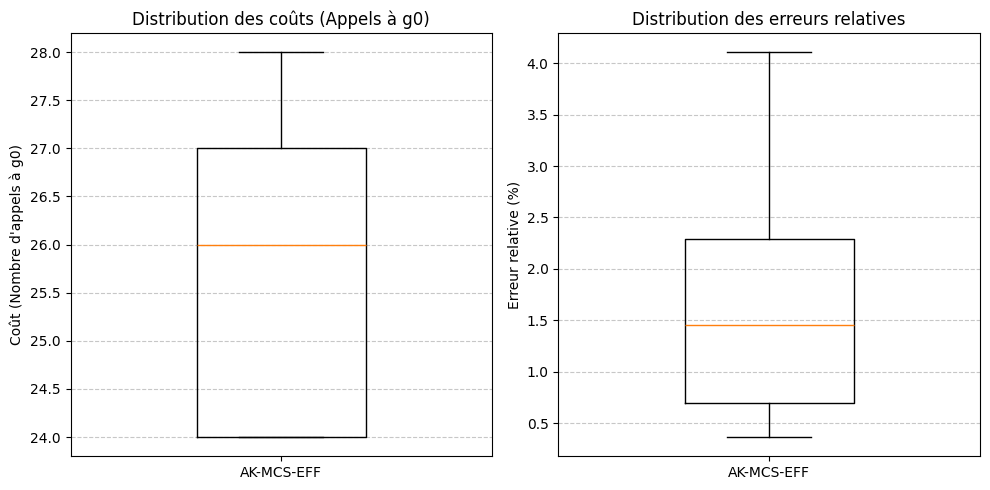

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 10-D
def g0_10d(x):
    """
    Fonction haute-fidélité g0 pour le problème à 10 dimensions.
    x : array de taille (N_samples, 10)
    """
    n = 10
    sigma = 0.2

    threshold = n + 3 * sigma * np.sqrt(n)

    g_val = threshold - np.sum(x, axis=1)

    return g_val.reshape(-1, 1)

if __name__ == "__main__":
    n_runs = 5
    n_mcs_train = 100000
    n_mcs_eval  = 1000000
    dim = 10

    m = 1.0
    s = 0.2
    sigma_norm = np.sqrt(np.log(1 + (s/m)**2))
    mu_norm = np.log(m) - 0.5 * sigma_norm**2

    ref_pf = 2.75e-3
    ref_costs = 62.45

    all_pfs = []
    all_calls = []
    all_errors = []

    print(f"Démarrage de {n_runs} lancements pour le problème 10D...\n")

    for run_idx in range(n_runs):
        print(f"--- RUN {run_idx + 1}/{n_runs} ---")

        S_train = np.random.lognormal(mean=mu_norm, sigma=sigma_norm, size=(n_mcs_train, dim))

        solver = AKMCS(performance_function=g0_10d, population=S_train, n_init=12, eff_stop=0.001)
        solver.run()

        S_eval = np.random.lognormal(mean=mu_norm, sigma=sigma_norm, size=(n_mcs_eval, dim))

        y_pred_final = solver.model.predict_values(S_eval)
        final_pf = np.sum(y_pred_final <= 0) / n_mcs_eval

        calls = len(solver.doe_y)
        error = abs(final_pf - ref_pf) / ref_pf * 100

        all_pfs.append(final_pf)
        all_calls.append(calls)
        all_errors.append(error)

        print(f"-> Fin du Run {run_idx + 1} : Appels = {calls}, Pf = {final_pf:.6e}, Erreur = {error:.2f}%\n")

    print("=========================================")
    print(" RÉSULTATS MOYENS SUR LES 5 LANCEMENTS   ")
    print("=========================================")
    print(f"Pf moyen     : {np.mean(all_pfs):.6e} (Réf Table 5 : {ref_pf:.6e})")
    print(f"Coût moyen   : {np.mean(all_calls):.1f} appels (Réf Table 5 : {ref_costs})")
    print(f"Erreur moy.  : {np.mean(all_errors):.2f}%")


    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.boxplot(all_calls, widths=0.4)
    plt.xticks([1], ['AK-MCS-EFF'])
    plt.ylabel('Coût (Nombre d\'appels à g0)')
    plt.title('Distribution des coûts (Appels à g0)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.boxplot(all_errors, widths=0.4)
    plt.xticks([1], ['AK-MCS-EFF'])
    plt.ylabel('Erreur relative (%)')
    plt.title('Distribution des erreurs relatives')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()